In [44]:
import pandas as pd

In [45]:
df = pd.read_csv("C:/Users/16692/Downloads/archive (3)/linear_equations_2_variables.csv", encoding='latin-1')

In [46]:
df.head()

,a1,b1,c1,a2,b2,c2,x,y
0,16,37,-75,60,-40,99,-0.231818,2.127273
1,-79,13,31,-27,-3,-19,-0.261905,-3.976190
2,-85,-66,94,54,83,-100,0.344314,0.980808
3,66,-40,-82,-53,-26,70,1.285714,0.071429
4,53,5,-68,-96,-100,-59,1.471992,-2.003112


In [47]:
from sklearn.model_selection import train_test_split 

In [48]:
X=df[['a1','b1','c1','a2','b2','c2']]
y=df[['x','y']]

In [49]:
X_train , X_test , y_train , y_test = train_test_split(X,y,random_state=42,test_size=0.2)
X_val , X_test , y_val , y_test = train_test_split(X , y, test_size=0.5 , random_state=42)

 Model 1 : Linear Regression 

In [50]:
from sklearn.linear_model import LinearRegression 
reg = LinearRegression()
reg.fit(X_train , y_train)

LinearRegression()

In [51]:
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score
import numpy as np 
def evaluate(model , X , y):
    y_predict=model.predict(X)
    mae=mean_absolute_error(y , y_predict)
    rmse= np.sqrt(mean_squared_error(y,y_predict))
    r2= r2_score(y,y_predict)
    return mae , rmse ,r2

In [53]:
mae_val , rmse_val , r2_val = evaluate(reg,X_val , y_val)
mae_test , rmse_test ,r2_test= evaluate (reg , X_test , y_test)
print(f"Validation Set -> MAE : {mae_val} , RMSE : {rmse_val} , R2 : {r2_val}")
print(f"Test Set -> MAE : {mae_test} , RMSE : {rmse_test} , R2 : {r2_test}")

Validation Set -> MAE : 5.36085599575511 , RMSE : 73.92168060860837 , R2 : 0.00013651207517512143
Test Set -> MAE : 4.978093404275626 , RMSE : 63.960077817906416 , R2 : -0.00014222715471834402


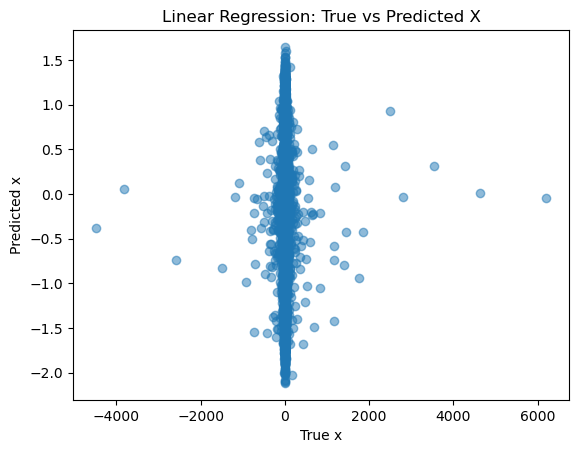

In [55]:
import matplotlib.pyplot as plt
y_pred= reg.predict(X_test)
plt.scatter(y_test["x"], y_pred[:, 0], alpha=0.5)
plt.xlabel("True x")
plt.ylabel("Predicted x")
plt.title("Linear Regression: True vs Predicted X")
plt.show()


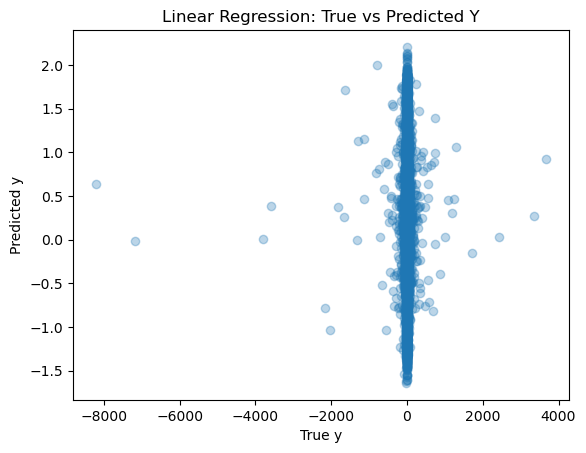

In [56]:
import matplotlib.pyplot as plt
plt.scatter(y_test["y"], y_pred[:, 1], alpha=0.3)
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("Linear Regression: True vs Predicted Y")
plt.show()

